# `dfs` — DFS 알고리즘 데모

[`algorithms/graph/dfs.py`](dfs.py) 는 textbook recursive DFS — `("visit", u, parent)` 이벤트를 yield 한다.

[`algorithms/graph/trace.py`](trace.py) 의 `@trace` 데코레이터가 `dfs.visits` · `dfs.walks` helper 를 자동 부여한다. 별도 `dfs_walks` 함수 · `Visit`/`TreeEdge` import 불필요.

In [1]:
import sys

sys.path.insert(0, '../..')

import core.graph as g
from algorithms.graph.dfs import dfs

a, b, c, d, e, f = g.vertices('a', 'b', 'c', 'd', 'e', 'f')

def show(graph, start):
    """원본 그래프 위에 DFS chain walk 들을 색깔별로 강조."""
    return graph._to_graphviz(highlight=dfs.walks(graph, start))

## 0. textbook 사용법

`dfs(g, a)` — `("visit", u, parent)` 이벤트 iterator. `dfs.visits(g, a)` 로 정점 list만 출력.

In [2]:
g3 = g.UnweightedGraph()
for u, v in [(a, b), (a, c), (b, d), (b, e), (c, f)]:
    g3.add_edge(u, v)

for u in dfs.visits(g3, a):
    print(u)

a
b
d
e
c
f


## 1. Path — `a-b-c-d`

분기 없는 선형 → walk 1개 (전체 한 색).

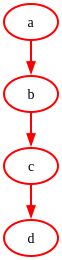

In [3]:
show(g.Graph(a - b - c - d), a)

## 2. Cycle — `a-b-c-a`

DFS 트리는 분기 없는 선형이라 walk 1개. cycle-closing edge 는 트리 외.

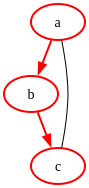

In [4]:
show(g.Graph(a - b - c - a), a)

## 3. Tree (분기)

방문 순서로 chain 이 끊김 → 3개 walk: `a→b→d`, `b→e`, `a→c→f`. 공유 정점은 multi-color border.

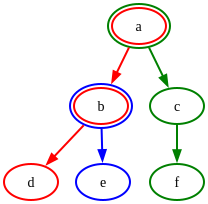

In [5]:
show(g3, a)

## 4. K4 — 완전 그래프

DFS 트리는 Hamiltonian path 1개 → walk 1개. 나머지 3개 간선은 트리 외.

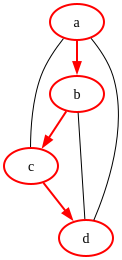

In [6]:
show(g.Graph.complete(a, b, c, d), a)

## 5. Directed — `a → b → c, a → c`

back edge `a→c` 는 트리 외. DFS 트리: `a→b→c` — walk 1개.

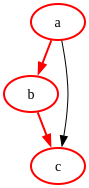

In [7]:
g5 = g.UnweightedGraph(kind=g.EdgeKind.DIRECTED)
for u, v in [(a, b), (b, c), (a, c)]:
    g5.add_edge(u, v)

show(g5, a)

## 6. 고립 정점

`start` 가 외톨이 → 빈 list → 강조 없음.

walks: []


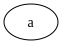

In [8]:
g6 = g.UnweightedGraph()
g6.add_vertex(a)

print('walks:', dfs.walks(g6, a))
show(g6, a)

## 7. 큰 격자 — `5×5` grid

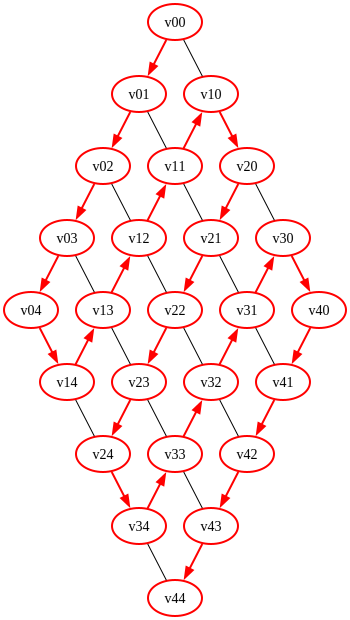

In [9]:
grid = g.Graph.grid(5, 5)
show(grid, grid.get_vertex('v00'))

## 8. Petersen graph

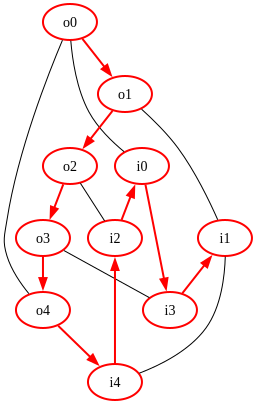

In [10]:
pet = g.Graph.petersen()
show(pet, pet.vertices()[0])

## 9. raw 이벤트 스트림

`dfs(g, a)` 직접 소비 — `("visit", u, parent)` 이벤트 출력. root 는 `parent=None`.

In [11]:
for event in dfs(g3, a):
    match event:
        case ("visit", u, None):
            print(f"  visit {u}  (root)")
        case ("visit", u, parent):
            print(f"  visit {u}  parent={parent}")

  visit a  (root)
  visit b  parent=a
  visit d  parent=b
  visit e  parent=b
  visit c  parent=a
  visit f  parent=c
